<a href="https://colab.research.google.com/github/14003771CR/Text-Mining-Image-Recognition.-Proyecto-Final/blob/main/Problema_2_cnn_frutas_vegetales_Cyndi_Raxjal_14003771.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cyndi Marjorie Nohemy Raxjal Pirir 14003771

# Text Mining & Image Recognition
## Proyecto Final

### Problema 2 — Fruits and Vegetables Recognizer (CNN)


In [1]:
# !pip install kagglehub -q
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2

# Fijamos semillas para que el entrenamiento sea reproducible entre corridas.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


### 1. Descarga del dataset (Kaggle)

In [2]:
import kagglehub

path = kagglehub.dataset_download("muhriddinmuxiddinov/fruits-and-vegetables-dataset")
print("Path to dataset files:", path)

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    if level <= 1:
        print("  " * level + os.path.basename(root) or root)


Using Colab cache for faster access to the 'fruits-and-vegetables-dataset' dataset.
Path to dataset files: /kaggle/input/fruits-and-vegetables-dataset
fruits-and-vegetables-dataset
  Fruits_Vegetables_Dataset(12000)


### 2. Selección de 3 frutas y 3 vegetales

```
Fruits_Vegetables_Dataset(12000)/
├── Fruits/
│   ├── FreshApple/ FreshBanana/ FreshMango/ FreshOrange/ FreshStrawberry/
│   └── RottenApple/ RottenBanana/ RottenMango/ RottenOrange/ RottenStrawberry/
└── Vegetables/
    ├── FreshBellpepper/ FreshCarrot/ FreshCucumber/ FreshPotato/ FreshTomato/
    └── RottenBellpepper/ RottenCarrot/ RottenCucumber/ RottenPotato/ RottenTomato/
```

Cada fruta/verdura viene en dos versiones: **fresca** y **podrida**. Para el ejercicio de reconocimiento de frutas y vegetales usamos solo las clases **Fresh**.

Elegimos:
- **Frutas:** FreshApple, FreshBanana, FreshMango
- **Vegetales:** FreshCarrot, FreshPotato, FreshTomato

Como el dataset no viene dividido, generamos nosotros los splits **train / validation /
test** en proporción 70% / 15% / 15%, con semilla fija para que sea reproducible.

In [3]:
BASE = os.path.join(path, "Fruits_Vegetables_Dataset(12000)")

for grupo in ["Fruits", "Vegetables"]:
    d = os.path.join(BASE, grupo)
    print(grupo, "->", sorted(os.listdir(d)))


Fruits -> ['FreshApple', 'FreshBanana', 'FreshMango', 'FreshOrange', 'FreshStrawberry', 'RottenApple', 'RottenBanana', 'RottenMango', 'RottenOrange', 'RottenStrawberry']
Vegetables -> ['FreshBellpepper', 'FreshCarrot', 'FreshCucumber', 'FreshPotato', 'FreshTomato', 'RottenBellpepper', 'RottenCarrot', 'RottenCucumber', 'RottenPotato', 'RottenTomato']


In [4]:
import random

FRUITS = ["FreshApple", "FreshBanana", "FreshMango"]
VEGETABLES = ["FreshCarrot", "FreshPotato", "FreshTomato"]

WORK = "/content" if os.path.exists("/content") else "/kaggle/working"
FILTERED_BASE = os.path.join(WORK, "fruits_veg_subset")
if os.path.exists(FILTERED_BASE):
    shutil.rmtree(FILTERED_BASE)

random.seed(42)

def build_splits(grupo, clases, train_ratio=0.70, val_ratio=0.15):
    for nombre in clases:
        src = os.path.join(BASE, grupo, nombre)
        etiqueta = nombre.replace("Fresh", "").lower()  # FreshApple -> apple

        imgs = sorted(f for f in os.listdir(src)
                      if f.lower().endswith((".jpg", ".jpeg", ".png")))
        random.shuffle(imgs)

        n = len(imgs)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        splits = {
            "train": imgs[:n_train],
            "validation": imgs[n_train:n_train + n_val],
            "test": imgs[n_train + n_val:],
        }

        for split, files in splits.items():
            dst = os.path.join(FILTERED_BASE, split, etiqueta)
            os.makedirs(dst, exist_ok=True)
            for fname in files:
                shutil.copy(os.path.join(src, fname), dst)

        print(f"{nombre}: {n} imágenes -> train {len(splits['train'])}, "
              f"validation {len(splits['validation'])}, test {len(splits['test'])}")

build_splits("Fruits", FRUITS)
build_splits("Vegetables", VEGETABLES)

print("\nListo. Estructura final:", os.listdir(FILTERED_BASE))


FreshApple: 612 imágenes -> train 428, validation 91, test 93
FreshBanana: 623 imágenes -> train 436, validation 93, test 94
FreshMango: 605 imágenes -> train 423, validation 90, test 92
FreshCarrot: 619 imágenes -> train 433, validation 92, test 94
FreshPotato: 614 imágenes -> train 429, validation 92, test 93
FreshTomato: 604 imágenes -> train 422, validation 90, test 92

Listo. Estructura final: ['test', 'validation', 'train']


### 3. Data Augmentation y preprocesamiento

- Imágenes a color (RGB) para no perder información de color, relevante para distinguir
  frutas/verduras (p. ej. tomate vs. papa).
- Aumento de datos: rotación, desplazamiento, shear, zoom, flip horizontal y variación de
  brillo (simula distintas condiciones de iluminación).
- Redimensionado a 128×128 y normalización a [0, 1] vía `ImageDataGenerator`.

In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode="nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(FILTERED_BASE, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(FILTERED_BASE, "validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(FILTERED_BASE, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False,
)

NUM_CLASSES = train_gen.num_classes
print("Clases:", train_gen.class_indices)


Found 2571 images belonging to 6 classes.
Found 548 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Clases: {'apple': 0, 'banana': 1, 'carrot': 2, 'mango': 3, 'potato': 4, 'tomato': 5}


### 4. Tres arquitecturas de CNN a comparar

- **CNN_A (simple)**
- **CNN_B (profunda)**
- **CNN_C (transferencia)**

In [6]:
def build_model_a(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(16, (3, 3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="CNN_A_simple")
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def build_model_b(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ], name="CNN_B_deep")
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def build_model_c(input_shape, num_classes):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="CNN_C_transfer_MobileNetV2")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model


### 5. Entrenamiento

Para evitar que una red diverja a mitad de entrenamiento, agregamos dos callbacks:

- **EarlyStopping:** detiene el entrenamiento si `val_loss` deja de mejorar durante varias épocas, y restaura los mejores pesos vistos(`restore_best_weights=True`).
- **ReduceLROnPlateau:** si `val_loss` se estanca, reduce el learning rate a la mitad en vez de dejar que el optimizador siga dando pasos grandes y desestabilizándose.

Estos callbacks hacen que el resultado final sea el *mejor punto* alcanzado por cada red durante el entrenamiento, no lo que haya al llegar a la última época — así una corrida inestable no arruina la comparación.

In [7]:
INPUT_SHAPE = (*IMG_SIZE, 3)
EPOCHS = 15

def make_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
        ),
    ]

models_dict = {
    "CNN_A_simple": build_model_a(INPUT_SHAPE, NUM_CLASSES),
    "CNN_B_deep": build_model_b(INPUT_SHAPE, NUM_CLASSES),
    "CNN_C_transfer": build_model_c(INPUT_SHAPE, NUM_CLASSES),
}

histories = {}
for name, model in models_dict.items():
    print(f"\n=== Entrenando {name} ===")
    model.summary()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=make_callbacks(),
    )
    histories[name] = history


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=== Entrenando CNN_A_simple ===


Model: "CNN_A_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,742 (7.05 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 66s 615ms/step - accuracy: 0.5632 - loss: 1.2021 - val_accuracy: 0.8832 - val_loss: 0.4564 - learning_rate: 1.0000e-04
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 286ms/step - accuracy: 0.8491 - loss: 0.4792 - val_accuracy: 0.9434 - val_loss: 0.2451 - learning_rate: 1.0000e-04
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 288ms/step - accuracy: 0.9172 - loss: 0.2929 - val_accuracy: 0.9635 - val_loss: 0.1667 - learning_rate: 1.0000e-04
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 289ms/step - accuracy: 0.9339 - loss: 0.2264 - val_accuracy: 0.9690 - val_loss: 0.1184 - learning_rate: 1.0000e-04
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 288ms/step - accuracy: 0.9440 - loss: 0.1878 - val_accuracy: 0.9726 - val_loss: 0.1064 - learning_rate: 1.0000e-04
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 278ms/step - accuracy: 0.9479 - loss: 0.1702 - val_accuracy: 0.9726 - val_loss: 0.0881 - learning_rate: 1.0000e-04
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 286ms/step - acc

### 6. Evaluación y comparación de arquitecturas

In [8]:
results = {}
for name, model in models_dict.items():
    loss, acc = model.evaluate(test_gen)
    results[name] = {"test_loss": loss, "test_accuracy": acc}
    print(f"{name}: accuracy={acc:.4f}, loss={loss:.4f}")

results_df = pd.DataFrame(results).T
results_df


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.8853 - loss: 0.4257
CNN_A_simple: accuracy=0.8853, loss=0.4257
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.9534 - loss: 0.1597
CNN_B_deep: accuracy=0.9534, loss=0.1597
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 744ms/step - accuracy: 0.9785 - loss: 0.0628
CNN_C_transfer: accuracy=0.9785, loss=0.0628


,test_loss,test_accuracy
CNN_A_simple,0.425722,0.885305
CNN_B_deep,0.159678,0.953405
CNN_C_transfer,0.062777,0.978495


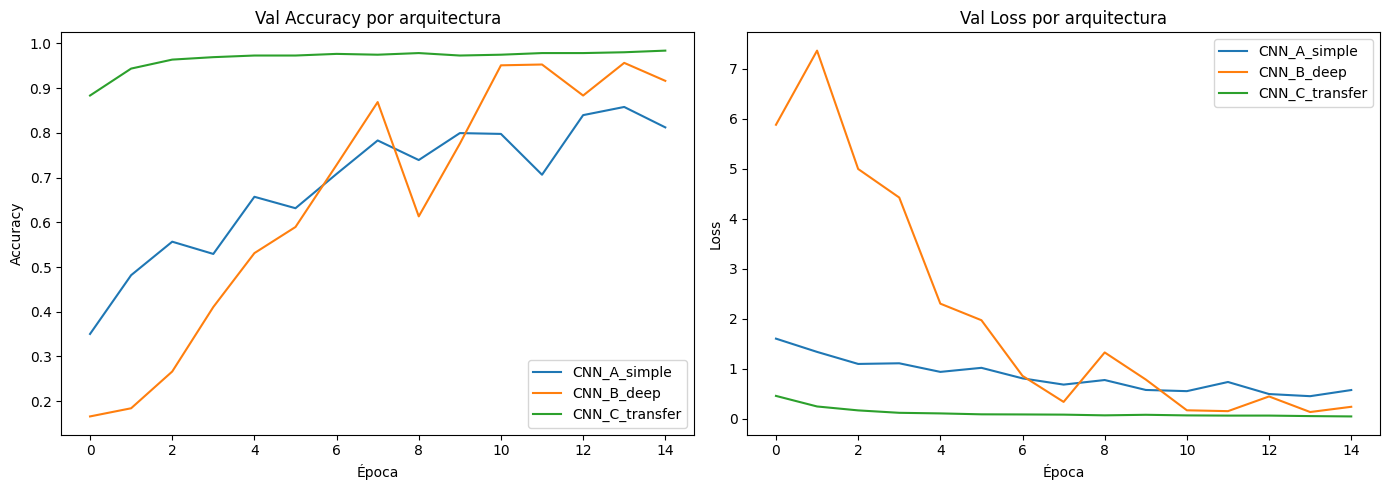

Mejor arquitectura según accuracy en test: CNN_C_transfer


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, history in histories.items():
    axes[0].plot(history.history["val_accuracy"], label=name)
    axes[1].plot(history.history["val_loss"], label=name)

axes[0].set_title("Val Accuracy por arquitectura")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].set_title("Val Loss por arquitectura")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()

best_model_name = results_df["test_accuracy"].astype(float).idxmax()
print(f"Mejor arquitectura según accuracy en test: {best_model_name}")


### Conclusiones:

| Arquitectura | Test Loss | Test Accuracy |
|---|---|---|
| CNN_A_simple | 0.4257 | 88.53% |
| CNN_B_deep | 0.1597 | 95.34% |
| **CNN_C_transfer (MobileNetV2)** | **0.0628** | **97.85%** |


- **CNN_A (simple) → 88.5%:** con solo 2 bloques convolucionales, la red aprende
  características muy básicas (bordes y manchas de color). Le alcanza para distinguir casos obvios, pero le cuesta más con formas parecidas (p. ej. tomate vs. manzana en ciertos ángulos), de ahí el loss más alto de las tres.

- **CNN_B (profunda) → 95.3%:** con 4 bloques convolucionales, BatchNormalization y Dropout, la red construye una jerarquía de características más rica (bordes → texturas → formas → partes del objeto). Una vez estabilizado el entrenamiento, supera claramente a CNN_A.

- **CNN_C (transferencia con MobileNetV2) → 97.9%, la mejor y la más estable:** parte   de pesos entrenados sobre 1.4 millones de imágenes de ImageNet, así que ya reconoce bordes, texturas, colores y formas generales de objetos antes de ver una sola imagen de fruta o vegetal. Como la base convolucional queda congelada (`base.trainable =  False`), solo se entrenan las capas densas finales — muchos menos parámetros libres,  lo que reduce tanto el riesgo de sobreajuste como la sensibilidad a la inicialización aleatoria.
